In [212]:
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/AxialAM/src/AxialAM.jl")

rot (generic function with 2 methods)

In [142]:
pam = am_presets()   # Lattice vectors, can be 2d or 3d
Rs = lattice_vectors(pam.a0)
sgnum = 17                               # point group triangular lattice p6mm
N = 100    
# high_sym_line = [:M, :Γ]            # Custom k-path over high symmetry momenta

100

## K-model

### Plotting the unitcell and the WignerSeitz cell

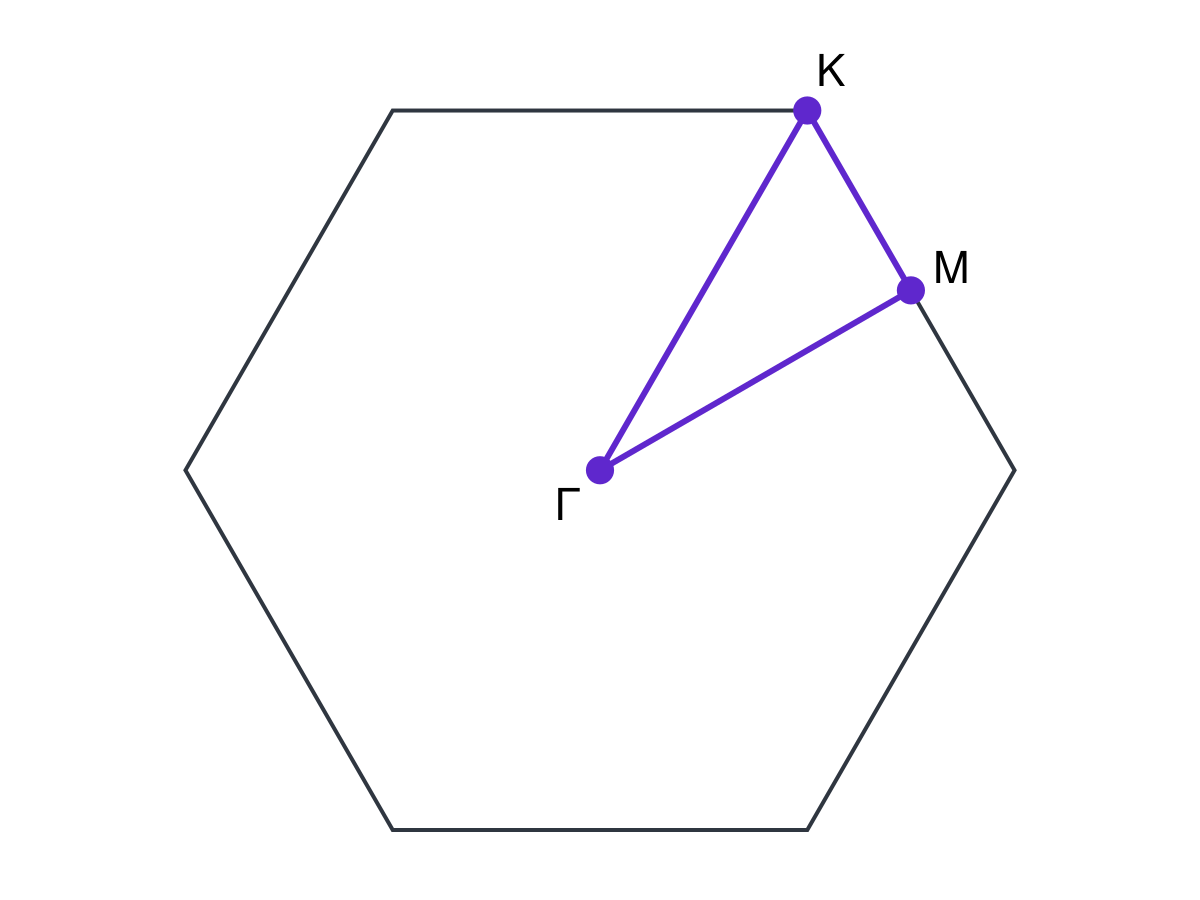

In [144]:
kp = cartesianize(irrfbz_path(sgnum, Rs))
Gs = basis(kp)      # primitive reciprocal basis associated with k-path
c = wignerseitz(Gs) # associated Brillouin zone
P= plot(c, kp)

In [146]:
Gs = basis(kp)   
Rs[1]'Gs[1]

6.283185307179586

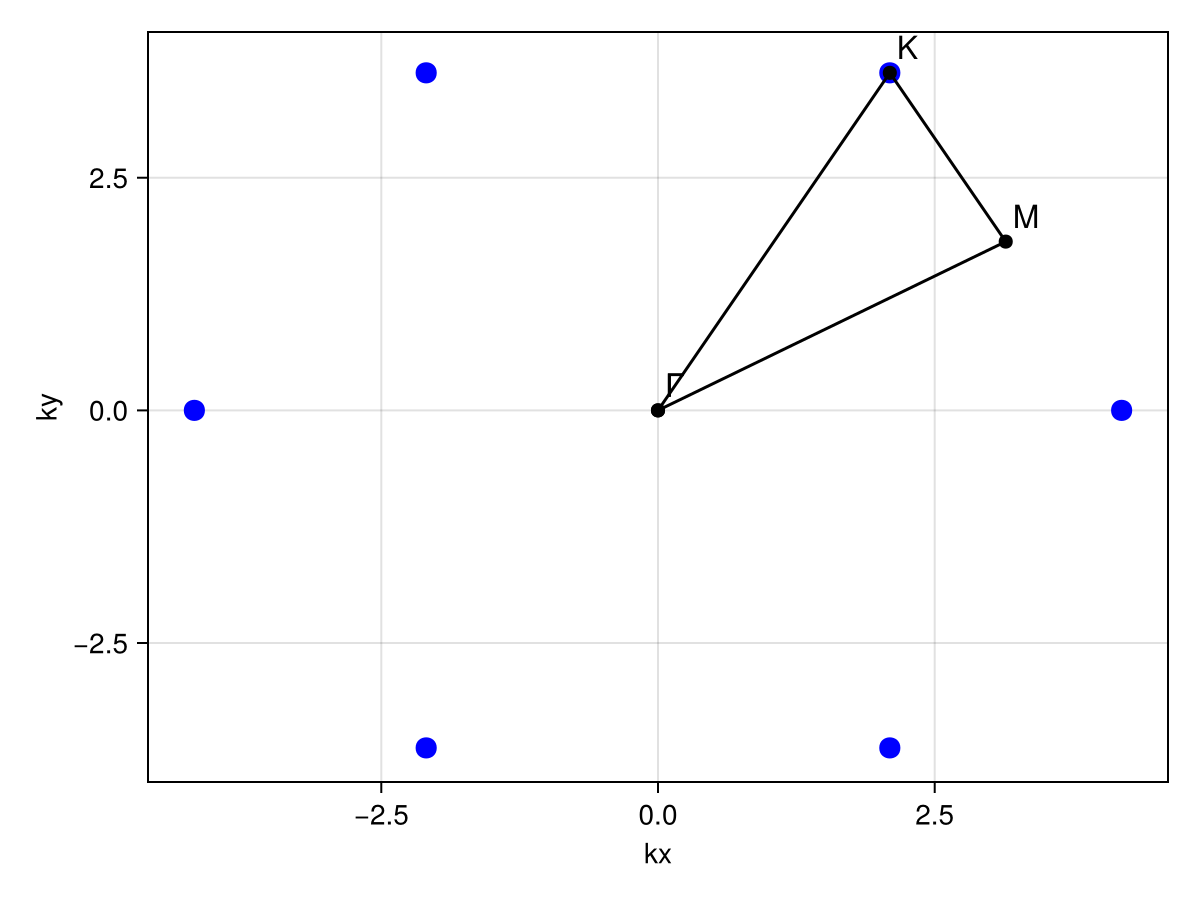

In [142]:
kp = kpath(Rs, sgnum, N);
plot_kpath(Rs, sgnum, N) 

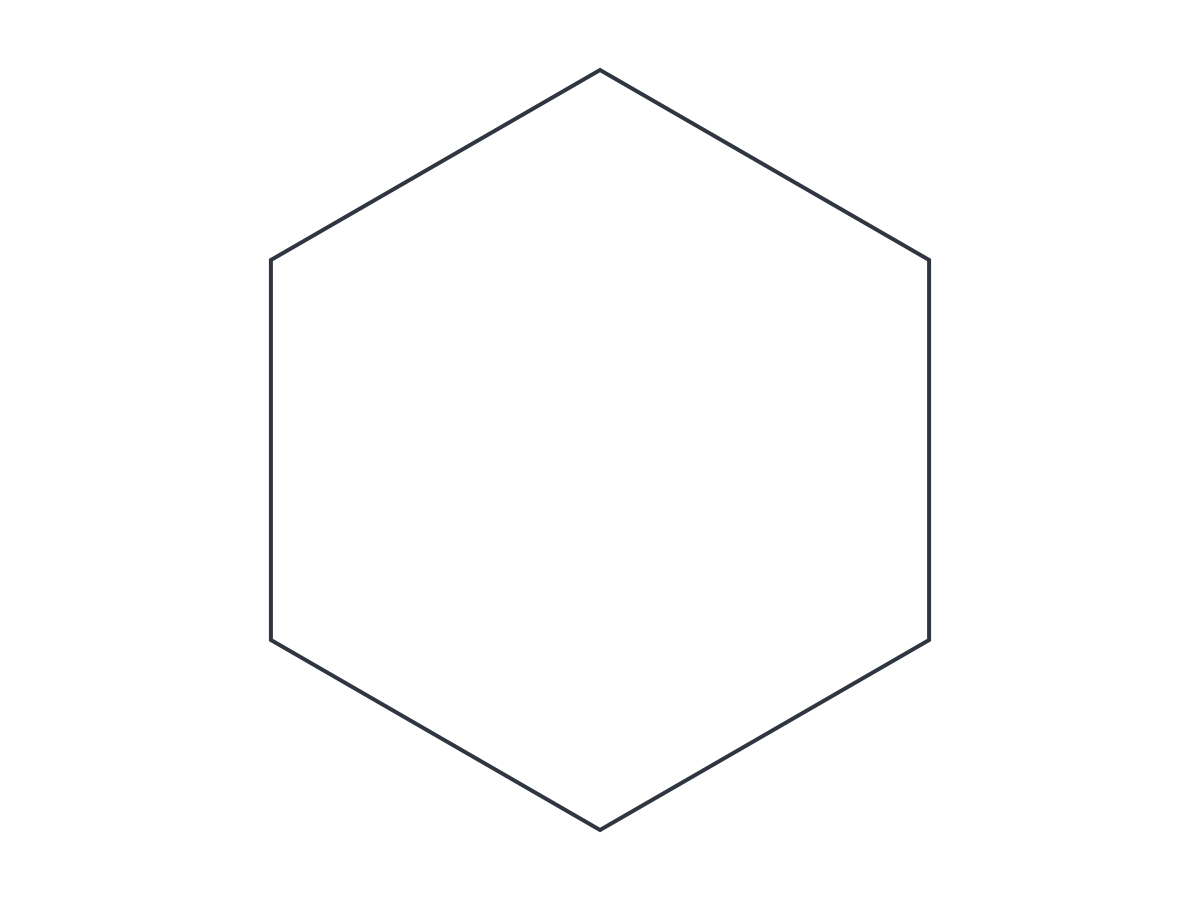

In [147]:
Rs = [[1.0, 0.0], [-0.5, √3/2]]
cᴿ = Brillouin.wignerseitz(Rs)
Pᴿ = plot(cᴿ)

### Bands

MethodError: MethodError: no method matching cos(::Vector{Vector{Float64}})

Closest candidates are:
  cos(!Matched::T) where T<:Union{Float32, Float64}
   @ Base special/trig.jl:98
  cos(!Matched::UniformScaling)
   @ LinearAlgebra /Applications/Julia-1.9.app/Contents/Resources/julia/share/julia/stdlib/v1.9/LinearAlgebra/src/uniformscaling.jl:173
  cos(!Matched::Complex{IntervalArithmetic.Interval{T}}) where T<:Union{AbstractFloat, Rational}
   @ IntervalArithmetic ~/.julia/packages/IntervalArithmetic/IbaUP/src/intervals/arithmetic/trigonometric.jl:218
  ...


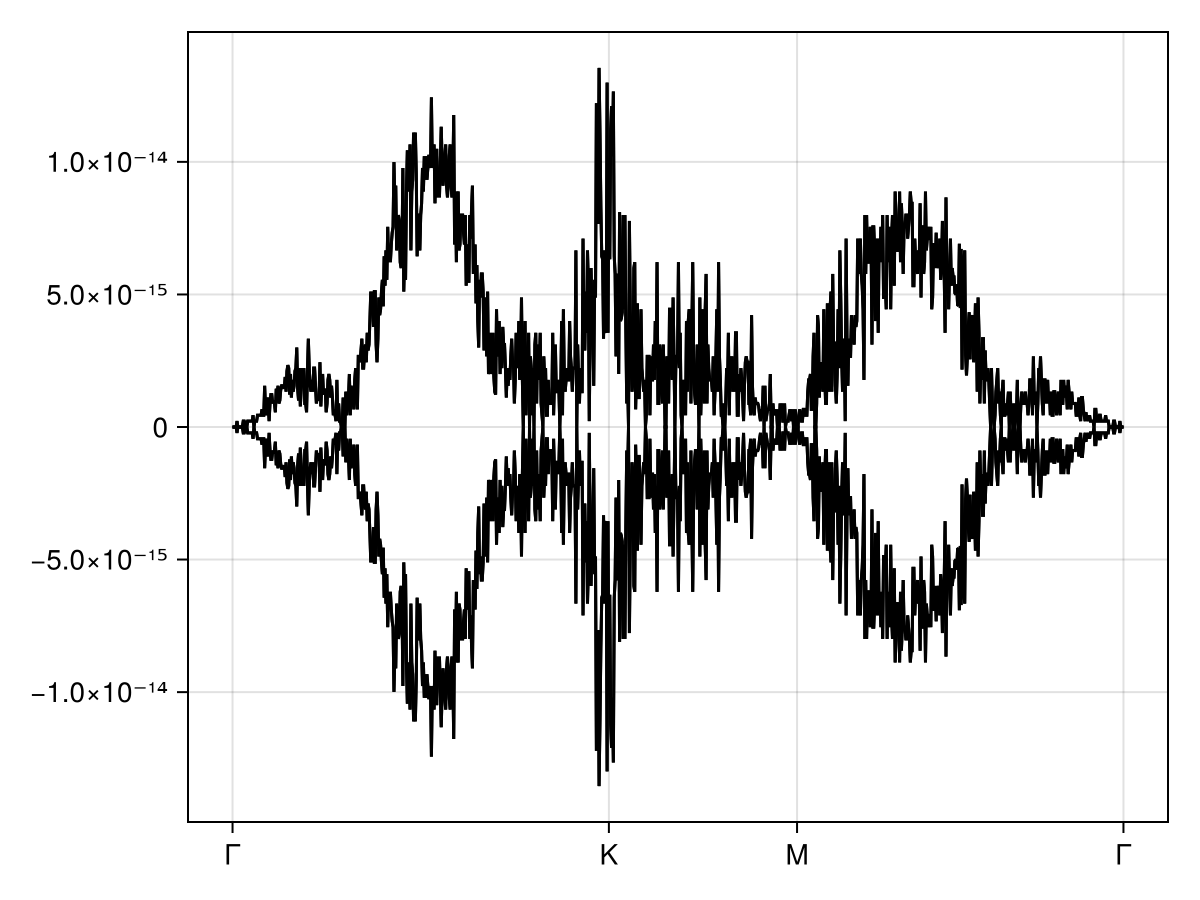

In [213]:
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/AxialAM/src/AxialAM.jl")
bands(sgnum, 1000, AM_presets(pam, a0 =1, t1 = 0, t4 = 1, neel = 0*[1,1,1]); high_sym_line = [:Γ, :K, :M, :Γ])

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/fernandopenaranda/.julia/packages/Makie/Y3ABD/src/scenes.jl:238


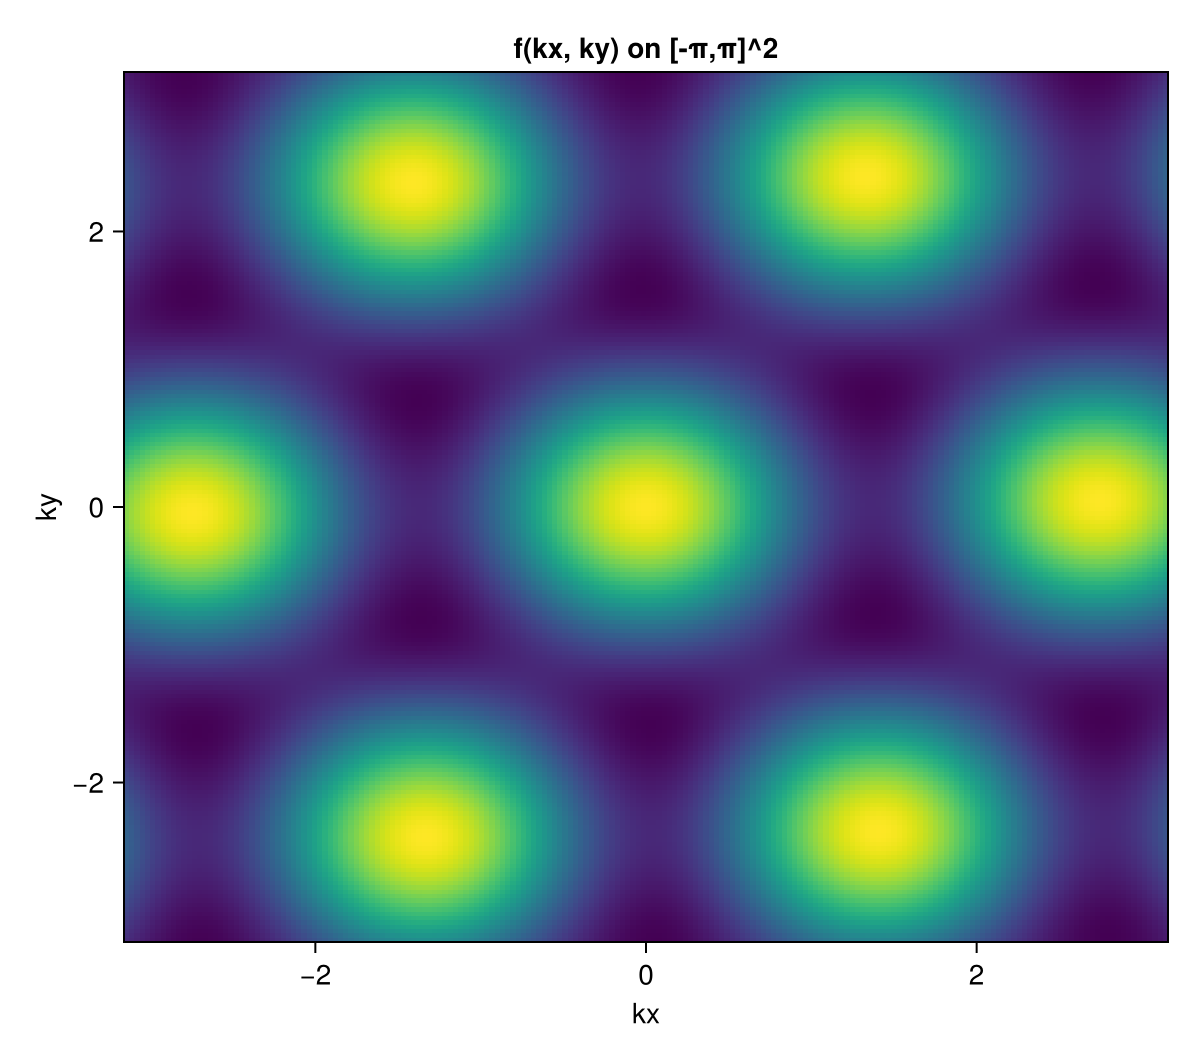

In [243]:
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/AxialAM/src/AxialAM.jl")
plot_am_formfactor()

In [223]:
am_character([0,0]
; a0 = 1)

UndefVarError: UndefVarError: `na` not defined

In [150]:
k_hamiltonian([1.,1], AM_presets(pam, a0 =.1, t1 = 0, t4 = 1e7, neel = 0 .* [1,1,1]))

-1.2925571046817907e-6


4×4 Matrix{ComplexF64}:
      0.0+0.0im  -25.8511+0.0im       0.0+0.0im       0.0+0.0im
 -25.8511+0.0im       0.0+0.0im       0.0+0.0im       0.0+0.0im
      0.0+0.0im       0.0+0.0im       0.0+0.0im  -25.8511+0.0im
      0.0+0.0im       0.0+0.0im  -25.8511+0.0im       0.0+0.0im

# Tight-binding

In [75]:
p = am_presets()
p = AM_presets(p, neel = [1,2,3])

AM_presets
  a0: Int64 1
  t1: Int64 1
  t4: Int64 1
  neel: Array{Int64}((3,)) [1, 2, 3]


In [76]:
qplot(supercell(am_lat(p), 19));

In [183]:
include("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/AxialAM/src/AxialAM.jl")
h = tb_hamiltonian(p)

[-2.0, 1.7320508075688772]
[-2.5, 0.8660254037844386]
[2.0, -1.7320508075688772]
[2.5, -0.8660254037844386]
[-0.5, 2.598076211353316]
[0.5, 2.598076211353316]
[-2.0, -1.7320508075688772]
[-2.5, -0.8660254037844386]
[-0.5, -2.598076211353316]
[0.5, -2.598076211353316]
[2.5, 0.8660254037844386]
[2.0, 1.7320508075688772]


Hamiltonian{Float64,2,2}: Hamiltonian on a 2D Lattice in 2D space
  Bloch harmonics  : 19
  Harmonic size    : 1 × 1
  Orbitals         : [4]
  Element type     : 4 × 4 blocks (ComplexF64)
  Onsites          : 1
  Hoppings         : 18
  Coordination     : 18.0

In [171]:
angle(a,b) = acos(dot(a,b)/(norm(a)*norm(b)))
angle([-0.5, 2.598076211353316],[0.5, 2.598076211353316])

0.3802512066929337

In [ ]:
qplot(h)

## TB Bands

In [141]:
b = Quantica.bands(h, subdiv((0, 2, 3, 4), 100); mapping = (0, 2, 3, 4) => (:Γ, :K, :M, :Γ));